In [7]:
import os, sys
repo_root = os.path.abspath('..')
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.data_loader import get_returns
from src.var_historical import historical_var, historical_cvar, var_summary
from src.var_parametric import parametric_var, parametric_cvar, parametric_summary

pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print("Imports OK")

Imports OK


In [8]:
TICKER = "NVDA"
START = "2020-01-01"
data = get_returns(TICKER, START)
returns = data['log_return']
print(f"Sample: {len(data)} days, {data.index.min().date()} to {data.index.max().date()}")

Sample: 1609 days, 2020-01-03 to 2026-05-29


In [9]:
hist_df  = var_summary(returns).rename(columns=lambda c: c if c == 'Confidence' else f'Hist_{c}')
param_df = parametric_summary(returns).rename(columns=lambda c: c if c == 'Confidence' else f'Param_{c}')

comparison = hist_df.merge(param_df, on='Confidence')
print(comparison.to_string(index=False))

Confidence  Hist_VaR_1d  Hist_CVaR_1d  Hist_VaR_10d  Hist_CVaR_10d  Param_VaR_1d  Param_CVaR_1d  Param_VaR_10d  Param_CVaR_10d
       95%       0.0489        0.0716        0.1547         0.2263        0.0517         0.0654         0.1634          0.2067
       99%       0.0805        0.1053        0.2546         0.3330        0.0740         0.0851         0.2340          0.2691


In [10]:
def make_gap_row(conf, horizon):
    hv = historical_var(returns, conf, horizon)
    pv = parametric_var(returns, conf, horizon)
    hc = historical_cvar(returns, conf, horizon)
    pc = parametric_cvar(returns, conf, horizon)
    return {
        'Confidence': f"{int(conf*100)}%",
        'Horizon_d': horizon,
        'Hist_VaR':  hv,
        'Param_VaR': pv,
        'VaR_Gap':   hv - pv,
        'Hist_CVaR':  hc,
        'Param_CVaR': pc,
        'CVaR_Gap':   hc - pc,
    }

gap_df = pd.DataFrame([make_gap_row(c, h) for c in (0.95, 0.99) for h in (1, 10)])
print(gap_df.to_string(index=False))

Confidence  Horizon_d  Hist_VaR  Param_VaR  VaR_Gap  Hist_CVaR  Param_CVaR  CVaR_Gap
       95%          1    0.0489     0.0517  -0.0027     0.0716      0.0654    0.0062
       95%         10    0.1547     0.1634  -0.0087     0.2263      0.2067    0.0196
       99%          1    0.0805     0.0740   0.0065     0.1053      0.0851    0.0202
       99%         10    0.2546     0.2340   0.0207     0.3330      0.2691    0.0639


Where parametric VaR breaks down

The gap columns are the headline of this notebook.

- At 95% confidence, parametric and historical are close — the 95th percentile isn't deep enough into the tail for fat-tailed behaviour to dominate. Parametric VaR can even slightly *exceed* historical here, because NVDA's large sigma (inflated by extreme days) widens the normal estimate at moderate confidence.
- At 99% confidence, parametric VaR comes in below historical. The normal distribution assigns near-zero probability to NVDA's -20% (COVID 2020) and -19% (DeepSeek Jan 2025) days, so its "worst loss" is too optimistic.
- The 99% CVaR gap is the largest — because CVaR averages the entire tail, and the tail is exactly where normality fails worst.

With NVDA's excess kurtosis of 4.12, normality is rejected. Using parametric VaR here understates 99% Expected Shortfall by ~2 percentage points — roughly $20,000/day of unaccounted tail risk on a $1M position.

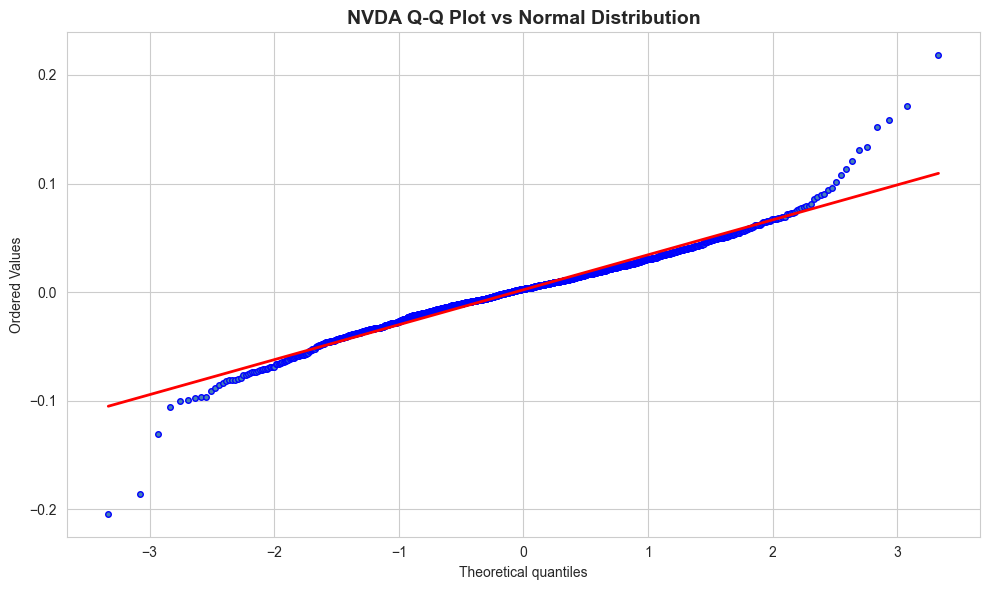

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
stats.probplot(returns, dist="norm", plot=ax)
ax.set_title(f'{TICKER} Q-Q Plot vs Normal Distribution', fontsize=14, fontweight='bold')
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('red')
ax.get_lines()[1].set_linewidth(2)
plt.tight_layout()
plt.savefig('../outputs/nvda_qqplot.png', dpi=120, bbox_inches='tight')
plt.show()

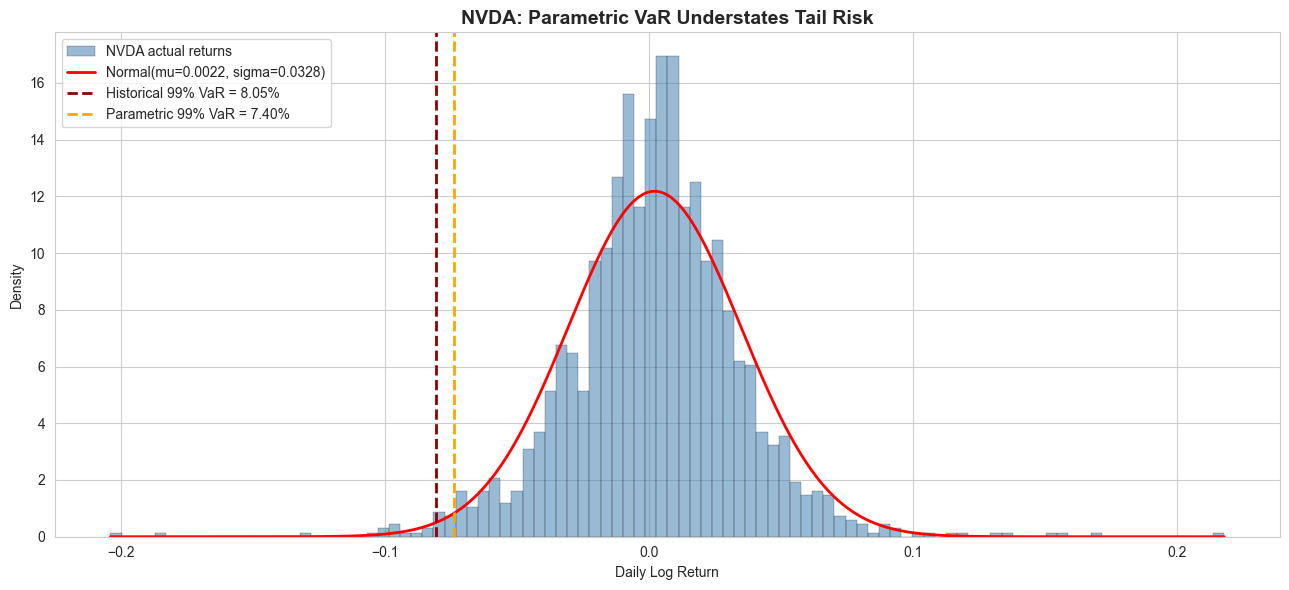

In [12]:
mu, sigma = returns.mean(), returns.std()
hv99 = historical_var(returns, 0.99)
pv99 = parametric_var(returns, 0.99)

fig, ax = plt.subplots(figsize=(13, 6))
ax.hist(returns, bins=100, density=True, alpha=0.55, color='steelblue',
        edgecolor='black', linewidth=0.3, label='NVDA actual returns')

x = np.linspace(returns.min(), returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
        label=f'Normal(mu={mu:.4f}, sigma={sigma:.4f})')

ax.axvline(-hv99, color='darkred', linestyle='--', linewidth=2,
           label=f'Historical 99% VaR = {hv99:.2%}')
ax.axvline(-pv99, color='orange', linestyle='--', linewidth=2,
           label=f'Parametric 99% VaR = {pv99:.2%}')

ax.set_title(f'{TICKER}: Parametric VaR Understates Tail Risk',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Daily Log Return')
ax.set_ylabel('Density')
ax.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/nvda_param_vs_hist.png', dpi=120, bbox_inches='tight')
plt.show()

Key takeaways — Parametric vs Historical VaR on NVDA

1. At 95%, the two methods roughly agree — below the deep tail, normality is a tolerable approximation.
2. At 99%, parametric understates VaR — the normal distribution can't see the COVID, 2022, and DeepSeek-class events that actually occurred.
3. CVaR gap is largest at 99% — the average of the tail is where normality fails worst (~2pp understatement).
4. The Q-Q plot makes the failure visible — data follows the line in the middle but diverges in both tails, with the left tail dropping below the line (losses worse than normal predicts).
5. Practical implication — a risk manager using parametric VaR on NVDA would systematically under-reserve capital.
6. Next: Monte Carlo VaR with normal and Student-t innovations. Student-t should close the gap by explicitly modelling fat tails.